In [76]:
import movement
from movement.io import load_dataset
from movement.filtering import filter_by_confidence, interpolate_over_time
from movement.kinematics import compute_velocity
from pathlib import Path

In [77]:
Path.home()

WindowsPath('C:/Users/moffi')

In [78]:
file_name = "T1_1D_04032026_inference.slp"
file_dir = Path.home() / "Documents" / "UCL" / "Sainsbury Wellcome Centre" / "OSSS" / "Hackathon data"
file_path = file_dir / file_name
file_path.exists()

True

In [79]:
ds = load_dataset(file_path, fps=25)

In [80]:
ds

<xarray.Dataset> Size: 281kB
Dimensions:     (time: 4135, space: 2, keypoint: 5, individual: 1)
Coordinates:
  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4
  * space       (space) <U1 8B 'x' 'y'
  * keypoint    (keypoint) <U9 180B 'snout' 'right_ear' ... 'center' 'headcap'
  * individual  (individual) <U4 16B 'id_0'
Data variables:
    position    (time, space, keypoint, individual) float32 165kB nan ... nan
    confidence  (time, keypoint, individual) float32 83kB 0.0 0.9264 ... nan nan
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    fps:              25.0
    time_unit:        seconds
    source_file:      C:/Users/moffi/Documents/UCL/Sainsbury Wellcome Centre/...

In [81]:
ds_headcap = ds.sel(keypoint=["headcap"])

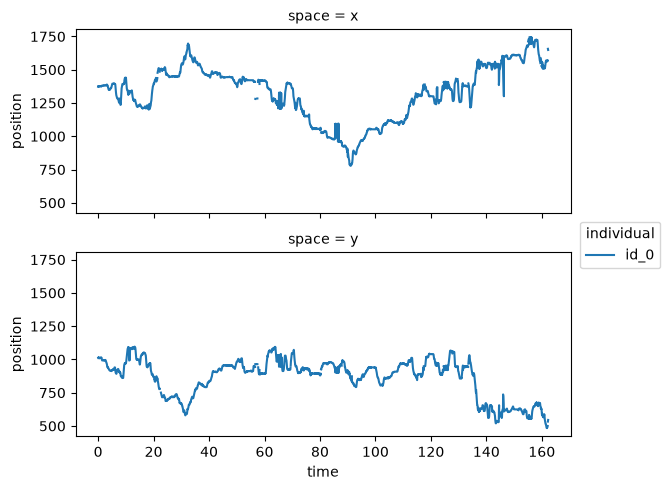

In [82]:
#visualise headcap position across space
headcap_pos = ds.position.sel(keypoint="headcap")
headcap_pos.plot.line(x="time", row="space", aspect=2, size=2.5)

(array([ 117.,    0.,    0.,   17.,   97.,  118.,  101.,  111.,  108.,
          88.,   99.,   86.,   74.,   74.,  103.,  132.,  316., 1562.,
         803.,   52.]),
 array([0.        , 0.05287459, 0.10574917, 0.15862375, 0.21149835,
        0.26437294, 0.31724751, 0.3701221 , 0.4229967 , 0.47587129,
        0.52874589, 0.58162045, 0.63449502, 0.68736964, 0.74024421,
        0.79311883, 0.8459934 , 0.89886796, 0.95174259, 1.00461721,
        1.05749178]),
 <BarContainer object of 20 artists>)

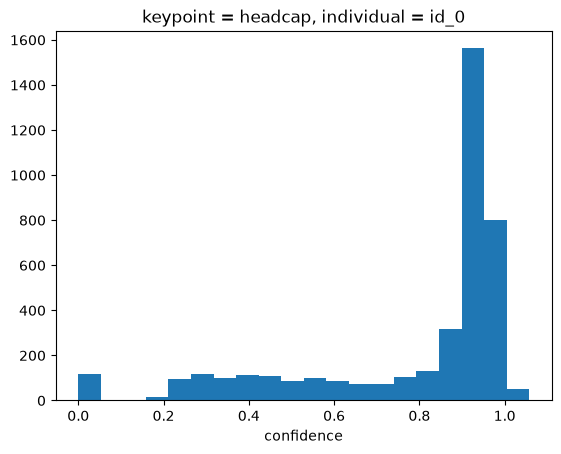

In [83]:
#Inspect outliers
ds_headcap.confidence.squeeze().plot.hist(bins=20)

In [84]:
#Filter outliers
ds_headcap.update(
    {
        "position": filter_by_confidence(
            ds_headcap.position, ds_headcap.confidence, threshold=0.8, print_report=True
        )
    }
)

Missing points (marked as NaN) in input:

keypoint             headcap
individual                  
id_0        194/4135 (4.69%)
Missing points (marked as NaN) in output:

keypoint              headcap
individual                   
id_0        1282/4135 (31.0%)


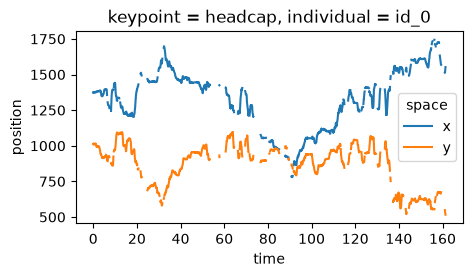

In [85]:
#Check filtering
ds_headcap.position.squeeze().plot.line(
    x="time", hue="space", aspect=2, size=2.5
)

In [87]:
#Interpolate filtered data
ds_headcap.update(
    {
        "position": interpolate_over_time(
            ds_headcap.position, max_gap=40, print_report=True
        )
    }
)

Missing points (marked as NaN) in input:

keypoint              headcap
individual                   
id_0        655/4135 (15.84%)
Missing points (marked as NaN) in output:

keypoint              headcap
individual                   
id_0        655/4135 (15.84%)


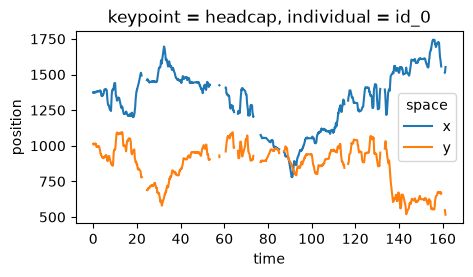

In [88]:
#Check interpolation
ds_headcap.position.squeeze().plot.line(
    x="time", hue="space", aspect=2, size=2.5
)

In [89]:
#Generate pipeline log
print(ds_headcap.position.log)

[
  {
    "operation": "filter_by_confidence",
    "datetime": "2026-08-21 12:52:57.125996",
    "confidence": "<xarray.DataArray 'confidence' (time: 4135, keypoint: 1, individual: 1)> Size: 17kB\n0.9351 0.9452 0.9775 0.9764 0.952 0.9495 0.9492 ... nan nan nan nan nan nan nan\nCoordinates:\n  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4\n  * keypoint    (keypoint) <U9 36B 'headcap'\n  * individual  (individual) <U4 16B 'id_0'",
    "threshold": "0.8",
    "print_report": "True"
  },
  {
    "operation": "interpolate_over_time",
    "datetime": "2026-08-21 12:52:57.259939",
    "method": "'linear'",
    "max_gap": "40",
    "print_report": "True"
  },
  {
    "operation": "interpolate_over_time",
    "datetime": "2026-08-21 12:53:29.503243",
    "method": "'linear'",
    "max_gap": "40",
    "print_report": "True"
  }
]
